# L7b Lab: SVD of a Reduced S&P 500 Return Matrix

The Fall 2025 market example depended on a hidden package dataset. This version commits a documented six-ticker, 181-day return matrix so every student sees the same data.

> **Learning objectives**
>
> - Load a dated multivariate return matrix with explicit provenance.
> - Center columns before analyzing common variation.
> - Compare singular-mode energy with reconstruction error.
> - Explain what a low-rank market factor does and does not mean.


## Setup and data

Run the local setup cell first. It activates the pinned course environment, loads every package used by this meeting, and includes the `Week07Core` module from [`../src/Week07Core.jl`](../src/Week07Core.jl), which provides the functions called below. The return matrix read below is committed at [`data/SP500-Reduced-LogReturns-2024.csv`](data/SP500-Reduced-LogReturns-2024.csv).

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes the meeting's local source. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


The setup cell completed, so the environment and this lab's local source are loaded. The cell below reads the committed return file into `market::NamedTuple`, whose fields are `dates::Vector{Dates.Date}`, `tickers::Vector{String}`, the log-return matrix `matrix::Matrix{Float64}`, and the source table `frame::DataFrame`.


In [2]:
market = load_return_matrix(joinpath(CHEME5800_L7B_DATA, "SP500-Reduced-LogReturns-2024.csv"))
(size = size(market.matrix), tickers = market.tickers, first_date = first(market.dates), last_date = last(market.dates))


(size = (181, 6), tickers = ["AAPL", "AMD", "JPM", "LLY", "MSFT", "XOM"], first_date = Dates.Date("2024-01-04"), last_date = Dates.Date("2024-09-23"))

## Center, decompose, and select rank


In [3]:
centered = market.matrix .- mean(market.matrix; dims = 1)
full = truncated_svd(centered, min(size(centered)...))
rank_one = truncated_svd(centered, 1)
rank_three = truncated_svd(centered, 3)

summary = DataFrame(
    rank = [1, 3, length(full.singular_values)],
    retained_energy = [rank_one.explained[1], rank_three.explained[3], 1.0],
    relative_error = [rank_one.relative_error, rank_three.relative_error, full.relative_error],
)
pretty_table(summary)


┌───────┬─────────────────┬────────────────┐
│  rank │ retained_energy │ relative_error │
│ Int64 │         Float64 │        Float64 │
├───────┼─────────────────┼────────────────┤
│     1 │        0.531358 │       0.684574 │
│     3 │        0.805611 │       0.440896 │
│     6 │             1.0 │    8.05022e-16 │
└───────┴─────────────────┴────────────────┘


In [4]:
@test size(market.matrix) == (181, 6)
@test rank_three.relative_error < rank_one.relative_error
@test full.relative_error < 1e-12
:market_svd_verified


:market_svd_verified

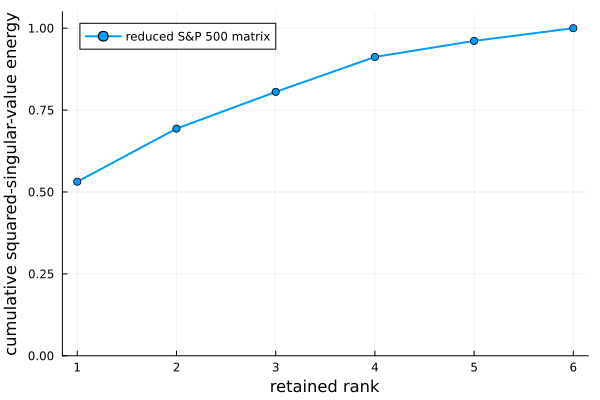

In [5]:
plot(full.explained; marker = :circle, lw = 2, ylim = (0, 1.05),
    xlabel = "retained rank", ylabel = "cumulative squared-singular-value energy",
    label = "reduced S&P 500 matrix")


## Interpretation

The first mode summarizes a shared movement across these six firms, but it is not 'the market' in a causal sense. The chosen tickers and date window define the matrix. Any generalization beyond this documented extract needs a broader dataset and out-of-sample check.
